# Task 11: Vision Transformer (ViT) Patch & Self-Attention

Extract image patches and compute Multi-Head Self-Attention in clear, short PyTorch code.

In [1]:
import torch
import matplotlib.pyplot as plt

### 1. Extract 4x4 Patches from a 16x16 Image

In [2]:
img = torch.randn(1, 1, 16, 16)  # 16x16 Single Channel Image

# Unfold image into 16 patches of size 4x4
patches = img.unfold(2, 4, 4).unfold(3, 4, 4).reshape(16, 16)
print('Extracted Patches Tensor Shape:', patches.shape)  # (16 patches, 16 pixels)

Extracted Patches Tensor Shape: torch.Size([16, 16])


### 2. Linear Projection & Self-Attention Matrix ($Q K^T$)

In [3]:
W_q = torch.randn(16, 8)
W_k = torch.randn(16, 8)

Q = patches @ W_q  # Query matrix
K = patches @ W_k  # Key matrix

# Scaled Dot-Product Attention Scores
attn_matrix = torch.softmax((Q @ K.T) / (8 ** 0.5), dim=-1)
print('Self-Attention Matrix Shape:', attn_matrix.shape)  # (16, 16)

Self-Attention Matrix Shape: torch.Size([16, 16])


### 3. Display Attention Matrix Heatmap

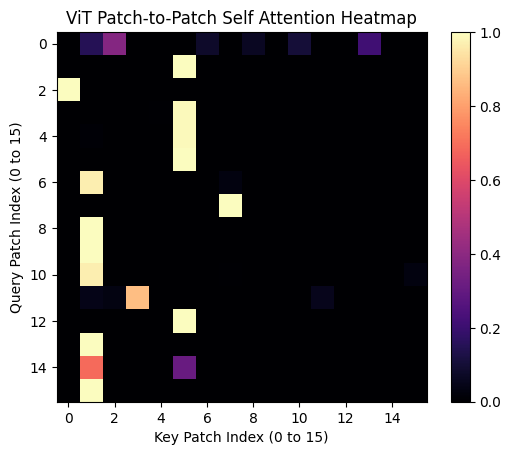

In [4]:
plt.imshow(attn_matrix.detach().numpy(), cmap='magma')
plt.title('ViT Patch-to-Patch Self Attention Heatmap')
plt.xlabel('Key Patch Index (0 to 15)')
plt.ylabel('Query Patch Index (0 to 15)')
plt.colorbar()
plt.show()